# 09: Exact Search and Score Functions

The previous notebook introduced GES, a greedy score-based search method. GES is fast and practical, but it is still greedy: it follows local score improvements rather than proving that no better graph exists anywhere in the search space.

We study **exact score-based search**. Exact search asks a sharper question: among all DAGs allowed by a search space, which graph optimizes the score? In causal-learn, `bic_exact_search` solves this problem for a BIC-style continuous score using dynamic programming or A* search over an order graph.

Exact search is valuable for learning and benchmarking because it shows what the best-scoring graph is under a score. But it is not a magic replacement for scalable discovery. The number of possible parent sets and variable orderings grows explosively with the number of variables, so exact search is usually reserved for small graphs, constrained graphs, or benchmarking smaller subproblems.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic graph-discovery datasets with known structural equations and known graph truth to study **Exact Search And Score Functions**. Known graph truth lets us see when an algorithm recovers edges, misses edges, or invents edges under violated assumptions.

Read each row as a draw from a structural causal system. Columns are observed variables, and in some notebooks omitted latent variables, environments, time ordering, or non-Gaussian mechanisms are deliberately introduced. The experiment studies graph scoring in a setting small enough to inspect carefully. That makes the search logic visible rather than hidden inside a black box.

The goal is to learn what each discovery method assumes and how its output should be audited.


## Mathematical Foundation

<!-- math-foundation-note -->

Score-based discovery searches over graphs by balancing model fit and complexity. A common score has the form

$$
\operatorname{BIC}(G)=-2\ell(\widehat\theta_G;X)+\lambda\operatorname{dim}(G)\log(n).
$$

Greedy methods move through graph space locally. Exact methods optimize more globally but become expensive as the number of variables grows. A high-scoring graph is an estimated model under a score, not automatic causal truth.





## Tutorial Workflow

### Runtime Note

This lesson is designed to run quickly by default, usually under **1-2 minutes** in this workspace. The exact-search examples use six or fewer variables and small structural constraints.

Exact search can become long-running when the number of variables grows. The notebook includes scaling diagnostics to show why. If you later try exact search on 10, 15, or more variables without strong constraints, runtime and memory can grow very quickly.


We will work through exact score-based discovery in this order:

1. Set up imports, paths, exact search, GES, and graph helpers.
2. Load the linear Gaussian example dataset and known synthetic graph.
3. Explain exact search, BIC local scores, A* search, dynamic programming, and super-structures.
4. Run exact BIC search with A* and DP and compare their search statistics.
5. Inspect local parent-set scores for one node.
6. Compare the exact graph with GES on the same data.
7. Use super-structures and max-parent constraints to show how prior search-space restrictions affect exact search.
8. Study sample-size and variable-count scaling.
9. Save a reporting checklist.

Every code cell has explanatory text before it and a short discussion after it, matching the style of the earlier tutorial notebooks.




### Exact Search Theory

Exact score-based search asks a precise optimization question: among all DAGs in the allowed search space, which graph has the best score?

This is different from GES. GES is greedy and follows local score improvements. Exact search uses dynamic programming or A* search to guarantee the optimum for the chosen score and constraints, at least within the graph size the algorithm can handle.

The phrase “exact” is easy to overread. Exact search is exact for the mathematical optimization problem it solves. It is not exact causal truth independent of score assumptions, sample noise, hidden variables, or model mismatch.

### DAG Search Space Grows Explosively

The number of possible DAGs grows super-exponentially with the number of variables. Even modest increases in variable count can make exhaustive search infeasible.

This is why exact search is usually used for small graphs, constrained subproblems, benchmarking, or teaching. It gives a valuable reference point: if GES and exact search agree on a small problem, we gain confidence that the greedy method found the global optimum for that score.

If they disagree, exact search helps reveal where greedy search got stuck or where constraints changed the optimal graph.




## Diagnostics and Interpretation

### Local Scores and Parent Sets

Most exact DAG search methods rely on decomposable scores:

$$
S(G) = \sum_i S_i(\mathrm{Pa}(X_i))
$$

This means each node's contribution depends only on its parent set. Exact search can precompute or cache scores for candidate parent sets, then combine those local choices while enforcing acyclicity.

The parent-set view is central. Instead of thinking “try every graph,” it is better to think “score possible parent sets for each node, then search for a compatible acyclic combination.”



### Parent Graphs and Order Graphs

A **parent graph** stores candidate parent sets and their local scores for each target variable. If a node has many possible parents, the number of candidate parent sets grows quickly.

An **order graph** represents possible variable orderings. A DAG is acyclic if its edges are consistent with at least one topological order. Searching over orders can therefore help enforce acyclicity without enumerating every DAG directly.

Dynamic programming and A* search use these structures to avoid redundant work. They are still expensive, but much smarter than naive enumeration.

### Dynamic Programming versus A* Search

Dynamic programming solves the exact search problem by building optimal solutions for smaller subsets of variables and combining them into larger solutions. It is systematic and exact, but memory can grow quickly because many subsets must be considered.

A* search treats the problem as a shortest-path or best-first search through an order graph. It uses a heuristic to prioritize promising partial orders and can be faster when the heuristic is informative.

Both methods are exact only when their assumptions and search settings preserve the full allowed search space. Constraints such as maximum parent count, super-graphs, or required edges change the optimization problem.

#### Constraints: Super-Graphs, Required Edges, and Max Parents

Exact search becomes more practical when the search space is constrained.

A **super-graph** says which edges are allowed. Exact search then finds the best DAG inside that allowed edge set. If the super-graph excludes a true edge, the exact optimum cannot recover it.

A **required-edge** constraint forces certain relationships to appear. This can encode strong domain knowledge but can also force a wrong graph.

A **max-parent** constraint limits how many parents each node may have. This reduces computation and can reduce overfitting, but it can also exclude real multi-parent mechanisms.

### What Exact Search Can and Cannot Claim

Exact search can certify that no other allowed DAG scores better under the chosen score. That is powerful for benchmarking and for small, well-constrained problems.

It cannot rescue a bad score, bad data, hidden confounding, or an excluded true graph. It can also be unstable across sample sizes because the best-scoring graph for a small noisy sample may differ from the best-scoring graph for the population.

A good exact-search report states the score, constraints, variable count, parent limits, runtime, memory concerns, and whether “exact” means exact over all DAGs or exact only over a restricted search space.

#### Setup

The setup cell imports causal-learn's exact BIC search, GES for comparison, plotting tools, and utilities for clean output. It also applies the same local BIC compatibility wrapper used in the GES notebook so GES comparison runs work under the current NumPy behavior. ExactSearch's own BIC scoring path does not need that wrapper.

In [1]:
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version
import contextlib
import io
import itertools
import os
import time
import warnings

# Keep matplotlib cache writes inside the repository so notebook execution works in restricted environments.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message=".*pkg_resources is deprecated.*")

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

from causallearn.search.ScoreBased.ExactSearch import bic_exact_search, bic_score_node, generate_parent_graph
import causallearn.search.ScoreBased.GES as ges_module
from causallearn.search.ScoreBased.GES import ges

# Resolve paths whether the notebook is run from the repository root or from this lesson folder.
CWD = Path.cwd()
if CWD.name == "causal_learn" and (CWD / "outputs").exists():
    NOTEBOOK_DIR = CWD
else:
    NOTEBOOK_DIR = (CWD / "notebooks" / "tutorials" / "causal_learn").resolve()

OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
for directory in [OUTPUT_DIR, DATASET_DIR, TABLE_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

NOTEBOOK_PREFIX = "09"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.facecolor"] = "white"


def local_score_BIC_from_cov(Data, i, PAi, parameters=None):
    """
    Compatibility wrapper for causal-learn GES BIC scoring under recent NumPy scalar behavior.
    
    Parameters
    ----------
    Data : array-like
        Data matrix passed by causal-learn into the local score function.
    i : int
        Target variable index for the local score calculation.
    PAi : list[int]
        Parent indices proposed for the target variable in the local score.
    parameters : dict
        Score-function parameters supplied by causal-learn.
    
    Returns
    -------
    float
        BIC-style local score for one target variable and candidate parent set.
    """
    cov, n = Data
    lambda_value = 0.5 if parameters is None else parameters.get("lambda_value", 0.5)
    sigma = float(cov[i, i])
    if len(PAi) > 0:
        yX = cov[np.ix_([i], PAi)]
        XX = cov[np.ix_(PAi, PAi)]
        try:
            XX_inv = np.linalg.inv(XX)
        except np.linalg.LinAlgError:
            XX_inv = np.linalg.pinv(XX)
        sigma = float(cov[i, i] - (yX @ XX_inv @ yX.T).item())
    sigma = max(sigma, 1e-12)
    return -0.5 * n * (1 + np.log(sigma)) - lambda_value * (len(PAi) + 1) * np.log(n)

# Patch only the imported module object used by GES during this lesson session.
ges_module.local_score_BIC_from_cov = local_score_BIC_from_cov

packages = ["causal-learn", "numpy", "pandas", "matplotlib", "seaborn"]
version_rows = []
for package in packages:
    try:
        package_version = version(package)
    except PackageNotFoundError:
        package_version = "not installed"
    version_rows.append({"package": package, "version": package_version})

package_versions = pd.DataFrame(version_rows)
package_versions.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(package_versions)


,package,version
0,causal-learn,0.1.4.5
1,numpy,2.4.4
2,pandas,3.0.2
3,matplotlib,3.10.9
4,seaborn,0.13.2


The version table and local GES wrapper make the comparison reproducible. The exact-search examples themselves rely on causal-learn's `bic_exact_search` and `bic_score_node` functions.

#### Load the Linear Gaussian Example Data

Exact BIC search uses a continuous BIC score, so we use the linear Gaussian dataset from the synthetic data notebook. This is the same friendly setting where BIC-GES performed well.

In [2]:
# Load the linear Gaussian data and the known synthetic true edge list.
linear_path = DATASET_DIR / "02_linear_gaussian.csv"
true_edge_path = TABLE_DIR / "02_base_true_dag_edges.csv"

required_paths = [linear_path, true_edge_path]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Run tutorial notebook 02 first. Missing files: " + ", ".join(missing_paths))

linear_df = pd.read_csv(linear_path)
true_edges = pd.read_csv(true_edge_path)
VARIABLES = list(linear_df.columns)

loaded_summary = pd.DataFrame(
    [
        {
            "dataset": "linear_gaussian",
            "rows": len(linear_df),
            "columns": linear_df.shape[1],
            "missing_cells": int(linear_df.isna().sum().sum()),
            "source_file": linear_path.name,
        }
    ]
)
loaded_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_loaded_dataset_summary.csv", index=False)

display(loaded_summary)
display(linear_df.head())
display(true_edges)

,dataset,rows,columns,missing_cells,source_file
0,linear_gaussian,2500,6,0,02_linear_gaussian.csv


,need,intent,match,engagement,renewal,support
0,0.249820,-0.372094,0.060245,0.667197,0.252766,-0.280058
1,0.683671,-0.210471,0.904969,1.004727,0.320095,-0.332215
2,-0.579752,-1.202671,-0.578579,-0.235444,-0.732431,0.594102
3,-0.902823,-0.077309,-0.771219,-0.531128,-0.105721,-1.503551
4,-1.985745,0.087297,-0.691315,-1.281731,-0.797906,-0.328219


,source,target,edge_type,mechanism
0,need,match,directed,Need changes what a good match means.
1,intent,match,directed,Current intent changes recommendation relevance.
2,match,engagement,directed,Better matching increases engagement depth.
3,intent,renewal,directed,Intent directly affects later value.
4,engagement,renewal,directed,Engagement contributes to renewal value.
5,engagement,support,directed,Engagement creates more chances for support contact.


The data are small enough in variable count for exact search and large enough in rows for stable local score estimates. The true graph will be used only for tutorial evaluation.

#### Exact Search Concept Map

Before running code, we define the key pieces. Exact search is not simply “try every DAG one by one.” causal-learn uses dynamic programming or A* over an order graph, with local parent-set scores cached for each node.

| concept | plain_language | why_it_matters |
| --- | --- | --- |
| local BIC score | Score one node given a proposed parent set. | Decomposable scores let the total graph score be built from local node scores. |
| parent graph | For each node, cache the best parent set available under different candidate predecessors. | Parent-set caching makes exact search much faster than naive enumeration. |
| order graph | Search over subsets or variable orderings rather than every DAG directly. | Dynamic programming and A* use this structure to find an optimal DAG for the score. |
| A* exact search | Use a priority queue and heuristic to search promising order-graph states first. | Can visit fewer states than full dynamic programming on some problems. |
| super-structure | Restrict which edges are allowed before search begins. | Good constraints reduce runtime; invalid constraints can force a wrong graph. |


The concept map frames exact search as optimized exhaustive search over a constrained space. The exact result is exact for the score and constraints, not exact causal truth in a universal sense.

#### Helper Functions

This helper cell converts adjacency matrices into edge tables, computes scores and graph metrics, and draws rounded-box graphs using the same visual style as earlier notebooks.

In [3]:
# Define reusable helpers for the Helper Functions section.
def adjacency_to_edge_table(adjacency, variables, label):
    """
    Convert a parent-row, child-column adjacency matrix into a tidy directed edge table.
    
    Parameters
    ----------
    adjacency : object
        Adjacency matrix encoding candidate parent-child edges.
    variables : list[str]
        Variables included in the graph, lag frame, or diagnostic.
    label : str
        Readable label attached to the method, scenario, or output row.
    
    Returns
    -------
    pd.DataFrame
        Graph edge table for adjacency to edge table, including node names and edge-orientation information where available.
    """
    rows = []
    for parent_idx, child_idx in zip(*np.where(adjacency > 0)):
        rows.append(
            {
                "run": label,
                "source": variables[int(parent_idx)],
                "edge_type": "-->",
                "target": variables[int(child_idx)],
            }
        )
    return pd.DataFrame(rows, columns=["run", "source", "edge_type", "target"])


def parse_causallearn_edge(edge):
    """
    Convert a causal-learn edge object into source, endpoint pattern, and target strings.
    
    Parameters
    ----------
    edge : object
        Graph edge object or edge row being parsed, classified, or drawn.
    
    Returns
    -------
    tuple[str, str, str]
        Source node, endpoint mark, and target node parsed from a causal-learn edge.
    """
    parts = str(edge).strip().split()
    if len(parts) != 3:
        return {"source": str(edge), "edge_type": "unknown", "target": "unknown"}
    return {"source": parts[0], "edge_type": parts[1], "target": parts[2]}


def graph_to_edge_table(graph, label):
    """
    Return a tidy edge table from a causal-learn graph object.
    
    Parameters
    ----------
    graph : object
        Graph object returned by causal-learn or constructed from the edge table.
    label : str
        Readable label attached to the method, scenario, or output row.
    
    Returns
    -------
    pd.DataFrame
        Edge table with source, target, edge mark, and method metadata.
    """
    rows = [parse_causallearn_edge(edge) for edge in graph.get_graph_edges()]
    edge_df = pd.DataFrame(rows, columns=["source", "edge_type", "target"])
    if edge_df.empty:
        edge_df = pd.DataFrame(columns=["source", "edge_type", "target"])
    edge_df.insert(0, "run", label)
    return edge_df


def directed_pairs(edge_df):
    """
    Extract definite directed pairs from an edge table.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Learned or oracle edge table being summarized or drawn.
    
    Returns
    -------
    set[tuple[str, str]]
        Ordered source-target pairs representing directed learned edges.
    """
    pairs = set()
    for row in edge_df.itertuples(index=False):
        if row.edge_type == "-->":
            pairs.add((row.source, row.target))
        elif row.edge_type == "<--":
            pairs.add((row.target, row.source))
    return pairs


def skeleton_pairs(edge_df):
    """
    Extract adjacencies while ignoring direction.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Learned or oracle edge table being summarized or drawn.
    
    Returns
    -------
    set[tuple[str, str]]
        Unordered node pairs representing the learned graph skeleton.
    """
    pairs = set()
    for row in edge_df.itertuples(index=False):
        if row.target != "unknown":
            pairs.add(frozenset([row.source, row.target]))
    return pairs


def summarize_against_truth(edge_df, truth_df, label):
    """
    Compute compact graph-recovery metrics against a truth table.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Learned or oracle edge table being summarized or drawn.
    truth_df : pd.DataFrame
        Oracle edge table used as the synthetic ground-truth benchmark.
    label : str
        Readable label attached to the method, scenario, or output row.
    
    Returns
    -------
    pd.DataFrame
        Graph-recovery summary table with edge counts, precision, recall, missing edges, and extra edges.
    """
    true_directed = set(zip(truth_df["source"], truth_df["target"]))
    true_skeleton = {frozenset(edge) for edge in true_directed}
    learned_directed = directed_pairs(edge_df)
    learned_skeleton = skeleton_pairs(edge_df)

    correct_directed = learned_directed & true_directed
    reversed_true = {(src, dst) for src, dst in true_directed if (dst, src) in learned_directed}
    missing_skeleton = true_skeleton - learned_skeleton
    extra_skeleton = learned_skeleton - true_skeleton

    unresolved_true = 0
    for src, dst in true_directed:
        pair = frozenset([src, dst])
        if pair in learned_skeleton and (src, dst) not in learned_directed and (dst, src) not in learned_directed:
            unresolved_true += 1

    directed_count = len(learned_directed)
    return pd.DataFrame(
        [
            {
                "run": label,
                "learned_edges_total": len(edge_df),
                "definite_directed_edges": directed_count,
                "true_edges": len(true_directed),
                "correct_directed_edges": len(correct_directed),
                "directed_precision": len(correct_directed) / directed_count if directed_count else np.nan,
                "directed_recall": len(correct_directed) / len(true_directed) if true_directed else np.nan,
                "reversed_true_edges": len(reversed_true),
                "unresolved_true_adjacencies": unresolved_true,
                "missing_true_adjacencies": len(missing_skeleton),
                "extra_adjacencies": len(extra_skeleton),
            }
        ]
    )


def total_exact_bic_score(data, adjacency):
    """
    Compute the total ExactSearch BIC score for a given adjacency matrix. Lower is better.
    
    Parameters
    ----------
    data : array-like or pd.DataFrame
        Data passed into the demonstrated method or score function.
    adjacency : object
        Adjacency matrix encoding candidate parent-child edges.
    
    Returns
    -------
    float
        Total BIC score for the candidate graph under the selected parent sets.
    """
    total = 0.0
    for child_idx in range(adjacency.shape[1]):
        parents = tuple(np.where(adjacency[:, child_idx] > 0)[0])
        total += float(bic_score_node(data, child_idx, parents))
    return total


def edge_table_to_adjacency(edge_df, variables):
    """
    Convert a directed edge table to an adjacency matrix using source rows and target columns.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Learned or oracle edge table being summarized or drawn.
    variables : list[str]
        Variables included in the graph, lag frame, or diagnostic.
    
    Returns
    -------
    np.ndarray
        Adjacency matrix whose nonzero entries encode the directed edges in the edge table.
    """
    index = {name: i for i, name in enumerate(variables)}
    adjacency = np.zeros((len(variables), len(variables)))
    for row in edge_df.itertuples(index=False):
        if row.edge_type == "-->" and row.source in index and row.target in index:
            adjacency[index[row.source], index[row.target]] = 1
        elif row.edge_type == "<--" and row.source in index and row.target in index:
            adjacency[index[row.target], index[row.source]] = 1
    return adjacency


def run_exact_search(data_df, label, search_method="astar", super_graph=None, include_graph=None, max_parents=None):
    """
    Run exact BIC search and return adjacency, edge table, stats, and elapsed time.
    
    Parameters
    ----------
    data_df : pd.DataFrame
        Dataset for the current simulated or observed experiment.
    label : str
        Readable label attached to the method, scenario, or output row.
    search_method : object
        Exact-search strategy used to score candidate graph structures.
    super_graph : object
        Graph representation of `super`.
    include_graph : object
        Graph representation of `include`.
    max_parents : object
        Maximum number of candidate parents allowed in the graph search.
    
    Returns
    -------
    tuple
        Tuple containing adjacency, edge_table, stats, elapsed.
    """
    start = time.perf_counter()
    adjacency, stats = bic_exact_search(
        data_df.to_numpy(),
        super_graph=super_graph,
        search_method=search_method,
        use_path_extension=True,
        verbose=False,
        include_graph=include_graph,
        max_parents=max_parents,
    )
    elapsed = time.perf_counter() - start
    edge_table = adjacency_to_edge_table(adjacency, list(data_df.columns), label=label)
    return adjacency, edge_table, stats, elapsed


def run_ges_bic(data_df, label):
    """
    Run BIC-GES quietly for comparison.
    
    Parameters
    ----------
    data_df : pd.DataFrame
        Dataset for the current simulated or observed experiment.
    label : str
        Readable label attached to the method, scenario, or output row.
    
    Returns
    -------
    tuple
        Tuple containing record, edge_table.
    """
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):
        record = ges(
            data_df.to_numpy(),
            score_func="local_score_BIC",
            node_names=list(data_df.columns),
            lambda_value=0.5,
        )
    edge_table = graph_to_edge_table(record["G"], label=label)
    return record, edge_table


GRAPH_POSITIONS = {
    "need": (0.11, 0.72),
    "intent": (0.11, 0.28),
    "match": (0.39, 0.50),
    "engagement": (0.62, 0.50),
    "renewal": (0.89, 0.72),
    "support": (0.89, 0.28),
}
NODE_LABELS = {name: name.title() for name in GRAPH_POSITIONS}
NODE_COLORS = {
    "need": "#e0f2fe",
    "intent": "#dbeafe",
    "match": "#ecfccb",
    "engagement": "#fef3c7",
    "renewal": "#fee2e2",
    "support": "#f3e8ff",
}


def trim_edge_to_box(start, end, box_w=0.145, box_h=0.095, gap=0.012):
    """
    Return edge endpoints that stop just outside source and target boxes.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate of the arrow or edge segment.
    end : tuple[float, float]
        Ending coordinate of the arrow or edge segment.
    box_w : float
        Width of the node box used to trim edge endpoints.
    box_h : float
        Height of the node box used to trim edge endpoints.
    gap : float
        Extra spacing between an edge endpoint and a node boundary.
    
    Returns
    -------
    tuple[tuple[float, float], tuple[float, float]]
        Start and end coordinates trimmed so the edge stops at box boundaries.
    """
    x0, y0 = start
    x1, y1 = end
    dx = x1 - x0
    dy = y1 - y0
    length = float(np.hypot(dx, dy))
    if length == 0:
        return start, end
    effective_w = box_w + 0.04
    effective_h = box_h + 0.04
    x_limit = (effective_w / 2) / abs(dx) if dx else np.inf
    y_limit = (effective_h / 2) / abs(dy) if dy else np.inf
    t = min(x_limit, y_limit) + gap / length
    return (x0 + dx * t, y0 + dy * t), (x1 - dx * t, y1 - dy * t)


def draw_box_graph(edge_df, title, path, note=None):
    """
    Draw a DAG-style graph with rounded boxes and visible arrowheads.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Learned or oracle edge table being summarized or drawn.
    title : str
        Title shown above the plot or saved artifact.
    path : str or pathlib.Path
        Output path where the figure or artifact is saved.
    note : str or None
        Optional explanatory note shown in the plot.
    
    Returns
    -------
    None
        Draws the graph diagram directly on the Matplotlib axes and saves it when requested.
    """
    fig, ax = plt.subplots(figsize=(12, 6.2))
    ax.set_axis_off()
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(0.04, 0.96)
    box_w, box_h = 0.145, 0.095

    for row in edge_df.itertuples(index=False):
        if row.source not in GRAPH_POSITIONS or row.target not in GRAPH_POSITIONS:
            continue
        raw_start = GRAPH_POSITIONS[row.source]
        raw_end = GRAPH_POSITIONS[row.target]
        if row.edge_type == "<--":
            raw_start, raw_end = raw_end, raw_start
        start, end = trim_edge_to_box(raw_start, raw_end, box_w=box_w, box_h=box_h)
        if row.edge_type in {"-->", "<--"}:
            arrowstyle = "-|>"
            mutation_scale = 18
            linewidth = 1.8
            color = "#334155"
        else:
            arrowstyle = "-"
            mutation_scale = 1
            linewidth = 1.5
            color = "#64748b"
        arrow = FancyArrowPatch(
            start,
            end,
            arrowstyle=arrowstyle,
            mutation_scale=mutation_scale,
            linewidth=linewidth,
            color=color,
            connectionstyle="arc3,rad=0.035",
            zorder=2,
        )
        ax.add_patch(arrow)

    for node, (x, y) in GRAPH_POSITIONS.items():
        rect = FancyBboxPatch(
            (x - box_w / 2, y - box_h / 2),
            box_w,
            box_h,
            boxstyle="round,pad=0.018",
            facecolor=NODE_COLORS[node],
            edgecolor="#1f2937",
            linewidth=1.1,
            zorder=5,
        )
        ax.add_patch(rect)
        ax.text(x, y, NODE_LABELS[node], ha="center", va="center", fontsize=10.5, fontweight="bold", zorder=6)

    if note:
        ax.text(0.50, 0.08, note, ha="center", va="center", fontsize=10, color="#475569")
    ax.set_title(title, pad=18, fontsize=14, fontweight="bold")
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


def truth_as_edge_table(truth_df, label="truth"):
    """
    Convert a truth table into a plotting-ready edge table.
    
    Parameters
    ----------
    truth_df : pd.DataFrame
        Oracle edge table used as the synthetic ground-truth benchmark.
    label : str
        Readable label attached to the method, scenario, or output row.
    
    Returns
    -------
    pd.DataFrame
        Oracle graph edge table with run label and directed-edge marks.
    """
    return truth_df.assign(run=label, edge_type="-->")[["run", "source", "edge_type", "target"]]


The helpers give the rest of the notebook a compact vocabulary: exact-search adjacency matrices become edge tables, edge tables become metrics, and every graph is drawn in the same style.

#### Draw the Reference DAG

We draw the known synthetic graph first so exact search results have a visual target. In applied work this graph would not be known.

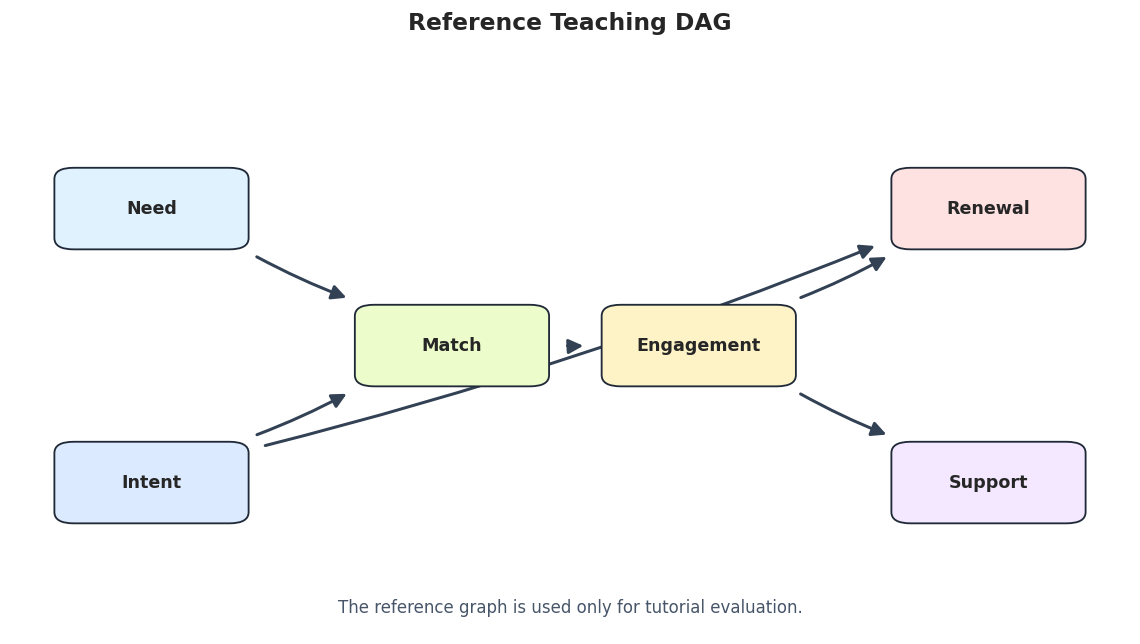

In [4]:
# Draw the reference synthetic graph.
true_edge_table = truth_as_edge_table(true_edges, label="true_graph")
true_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_true_dag.png"
draw_box_graph(
    true_edge_table,
    title="Reference Teaching DAG",
    path=true_graph_path,
    note="The reference graph is used only for tutorial evaluation.",
)

The reference graph has six directed edges. Exact BIC search will now look for the best-scoring DAG under its own score, not for this graph directly.

#### Exact BIC Search with A* and Dynamic Programming

causal-learn supports two exact-search methods here: A* and dynamic programming. Both should return the same optimal DAG under the same score and constraints. Their search statistics can differ because they traverse the order graph differently.

In [5]:
# Run exact BIC search with A* and dynamic programming.
exact_runs = []
exact_edge_tables = []
for method in ["astar", "dp"]:
    label = f"exact_bic_{method}"
    adjacency, edge_table, stats, elapsed = run_exact_search(
        linear_df,
        label=label,
        search_method=method,
        max_parents=None,
    )
    metrics = summarize_against_truth(edge_table, true_edges, label)
    exact_runs.append(
        {
            "run": label,
            "search_method": method,
            "elapsed_seconds": elapsed,
            "exact_bic_score_lower_is_better": total_exact_bic_score(linear_df.to_numpy(), adjacency),
            "learned_edge_count": int(adjacency.sum()),
            **stats,
        }
    )
    exact_edge_tables.append(edge_table.assign(search_method=method))

exact_search_stats = pd.DataFrame(exact_runs)
exact_search_edges = pd.concat(exact_edge_tables, ignore_index=True)
exact_search_metrics = pd.concat(
    [summarize_against_truth(table.drop(columns=["search_method"]), true_edges, table["run"].iloc[0]) for _, table in exact_search_edges.groupby("run")],
    ignore_index=True,
)

exact_search_stats.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_exact_search_stats.csv", index=False)
exact_search_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_exact_search_edges.csv", index=False)
exact_search_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_exact_search_metrics.csv", index=False)

display(exact_search_stats)
display(exact_search_edges)
display(exact_search_metrics)

,run,search_method,elapsed_seconds,exact_bic_score_lower_is_better,learned_edge_count,n_parent_graphs_entries,while_iter,for_iter,n_closed,max_n_opened,n_order_graph_nodes,n_order_graph_edges
0,exact_bic_astar,astar,0.015661,-9950.952924,6,109,36.0,120.0,36.0,20.0,NaN,NaN
1,exact_bic_dp,dp,0.016617,-9950.952924,6,109,NaN,NaN,NaN,NaN,64.0,148.0


,run,source,edge_type,target,search_method
0,exact_bic_astar,need,-->,match,astar
1,exact_bic_astar,intent,-->,match,astar
2,exact_bic_astar,intent,-->,renewal,astar
3,exact_bic_astar,match,-->,engagement,astar
4,exact_bic_astar,engagement,-->,renewal,astar
5,exact_bic_astar,engagement,-->,support,astar
6,exact_bic_dp,need,-->,match,dp
7,exact_bic_dp,intent,-->,match,dp
8,exact_bic_dp,intent,-->,renewal,dp
9,exact_bic_dp,match,-->,engagement,dp


,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,exact_bic_astar,6,6,6,6,1.0,1.0,0,0,0,0
1,exact_bic_dp,6,6,6,6,1.0,1.0,0,0,0,0


A* and dynamic programming return the same graph, as expected. The statistics show the machinery behind exact search: parent-graph entries, order-graph nodes, and search iterations.

#### Draw the Exact BIC Graph

The exact graph is the best-scoring DAG under causal-learn's exact BIC objective and the unconstrained six-variable search space.

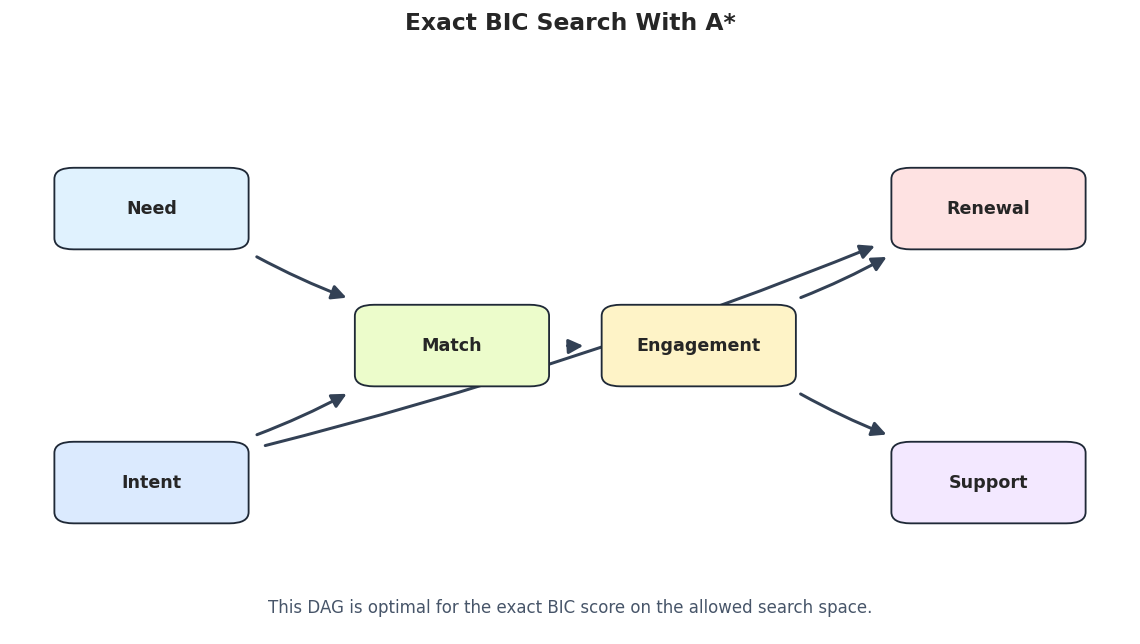

In [6]:
# Draw the A* exact-search graph.
exact_astar_edges = exact_search_edges[exact_search_edges["run"] == "exact_bic_astar"].drop(columns=["search_method"])
exact_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_exact_bic_astar_graph.png"
draw_box_graph(
    exact_astar_edges,
    title="Exact BIC Search With A*",
    path=exact_graph_path,
    note="This DAG is optimal for the exact BIC score on the allowed search space.",
)

In this friendly synthetic case, the exact BIC graph matches the reference DAG. The next section opens the local score logic that makes exact search possible.



#### Local Parent-Set Scores for `match`

Exact search works because the graph score decomposes by node. Here we focus on the `match` node and score possible parent sets. Lower BIC values are better for `bic_score_node`.

In [7]:
# Score candidate parent sets for the match node.
match_index = VARIABLES.index("match")
candidate_parent_names = [name for name in VARIABLES if name != "match"]
parent_score_rows = []
for parent_count in range(0, 4):
    for parent_names in itertools.combinations(candidate_parent_names, parent_count):
        parent_indices = tuple(VARIABLES.index(name) for name in parent_names)
        score = bic_score_node(linear_df.to_numpy(), match_index, parent_indices)
        parent_score_rows.append(
            {
                "child": "match",
                "parent_set": list(parent_names),
                "parent_count": parent_count,
                "local_bic_score_lower_is_better": float(score),
            }
        )

match_parent_scores = pd.DataFrame(parent_score_rows).sort_values("local_bic_score_lower_is_better")
match_parent_scores.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_match_parent_set_scores.csv", index=False)
display(match_parent_scores.head(15))

,child,parent_set,parent_count,local_bic_score_lower_is_better
16,match,"[need, intent, engagement]",3,-4479.089770
18,match,"[need, intent, support]",3,-3667.015172
17,match,"[need, intent, renewal]",3,-3648.117337
19,match,"[need, engagement, renewal]",3,-3556.411652
6,match,"[need, intent]",2,-3516.479864
10,match,"[intent, engagement]",2,-3275.416951
23,match,"[intent, engagement, support]",3,-3269.316850
22,match,"[intent, engagement, renewal]",3,-3268.865824
7,match,"[need, engagement]",2,-3180.792129
20,match,"[need, engagement, support]",3,-3173.301495


The best local parent sets for `match` include `need` and `intent`, which are its true direct parents in the synthetic graph. This local view explains part of why the full exact search recovers the intended structure.



#### Parent Graph Size for Each Node

Exact search caches possible parent sets in a parent graph for each target node. The code below counts how many parent-graph entries are generated for each node with and without a max-parent limit.

In [8]:
# Count parent-graph entries for each node under different max-parent settings.
parent_graph_rows = []
for max_parents in [1, 2, 3, len(VARIABLES)]:
    for node_idx, node_name in enumerate(VARIABLES):
        parent_graph = generate_parent_graph(
            linear_df.to_numpy(),
            node_idx,
            max_parents=max_parents,
        )
        parent_graph_rows.append(
            {
                "node": node_name,
                "max_parents": max_parents,
                "parent_graph_entries": len(parent_graph),
                "best_parent_set": [VARIABLES[int(idx)] for idx in parent_graph[0][0]],
                "best_local_bic_score_lower_is_better": float(parent_graph[0][1]),
            }
        )

parent_graph_summary = pd.DataFrame(parent_graph_rows)
parent_graph_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_parent_graph_entry_summary.csv", index=False)
display(parent_graph_summary)

,node,max_parents,parent_graph_entries,best_parent_set,best_local_bic_score_lower_is_better
0,need,1,5,[match],-1084.757041
1,intent,1,5,[renewal],-1936.585079
2,match,1,6,[engagement],-2793.639587
3,engagement,1,6,[match],-2793.639587
4,renewal,1,6,[intent],-1936.585079
5,support,1,6,[engagement],-1026.510792
6,need,2,12,"[intent, match]",-2208.258093
7,intent,2,11,"[need, match]",-2424.006541
8,match,2,15,"[need, intent]",-3516.479864
9,engagement,2,14,"[match, support]",-3139.027763


The parent-graph table shows why max-parent limits can matter. Smaller limits reduce the number of local structures considered, but they are only safe if the true graph does not require larger parent sets.



### Compare Exact Search with GES

GES is greedy, while exact search optimizes the BIC objective over the allowed DAG space. On this friendly dataset, both methods should agree. That agreement is useful because it tells us the greedy method did not get trapped in a worse local solution here.

In [9]:
# Run GES for comparison with exact BIC search.
ges_record, ges_edges = run_ges_bic(linear_df, label="bic_ges_linear_gaussian")
ges_adjacency = edge_table_to_adjacency(ges_edges, VARIABLES)
ges_metrics = summarize_against_truth(ges_edges, true_edges, "bic_ges_linear_gaussian")
exact_metrics = summarize_against_truth(exact_astar_edges, true_edges, "exact_bic_astar")

exact_vs_ges = pd.concat([exact_metrics, ges_metrics], ignore_index=True)
score_comparison = pd.DataFrame(
    [
        {
            "run": "exact_bic_astar",
            "exact_bic_score_lower_is_better": total_exact_bic_score(linear_df.to_numpy(), edge_table_to_adjacency(exact_astar_edges, VARIABLES)),
            "learned_edges_total": len(exact_astar_edges),
        },
        {
            "run": "bic_ges_linear_gaussian",
            "exact_bic_score_lower_is_better": total_exact_bic_score(linear_df.to_numpy(), ges_adjacency),
            "learned_edges_total": len(ges_edges),
        },
    ]
)

exact_vs_ges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_exact_vs_ges_metrics.csv", index=False)
score_comparison.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_exact_vs_ges_score_comparison.csv", index=False)
ges_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_ges_comparison_edges.csv", index=False)

display(score_comparison)
display(exact_vs_ges)
display(ges_edges)

,run,exact_bic_score_lower_is_better,learned_edges_total
0,exact_bic_astar,-9950.952924,6
1,bic_ges_linear_gaussian,-9950.952924,6


,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,exact_bic_astar,6,6,6,6,1.0,1.0,0,0,0,0
1,bic_ges_linear_gaussian,6,6,6,6,1.0,1.0,0,0,0,0


,run,source,edge_type,target
0,bic_ges_linear_gaussian,need,-->,match
1,bic_ges_linear_gaussian,intent,-->,match
2,bic_ges_linear_gaussian,intent,-->,renewal
3,bic_ges_linear_gaussian,match,-->,engagement
4,bic_ges_linear_gaussian,engagement,-->,renewal
5,bic_ges_linear_gaussian,engagement,-->,support


Exact search and GES agree in this case. That is reassuring, but it should not be assumed in every dataset. Exact search is most useful as a benchmark for small problems where the global optimum can actually be computed.



#### Plot Exact Search versus GES

The metric plot keeps the comparison concise. It also gives a consistent visual pattern with the earlier method-comparison notebooks.

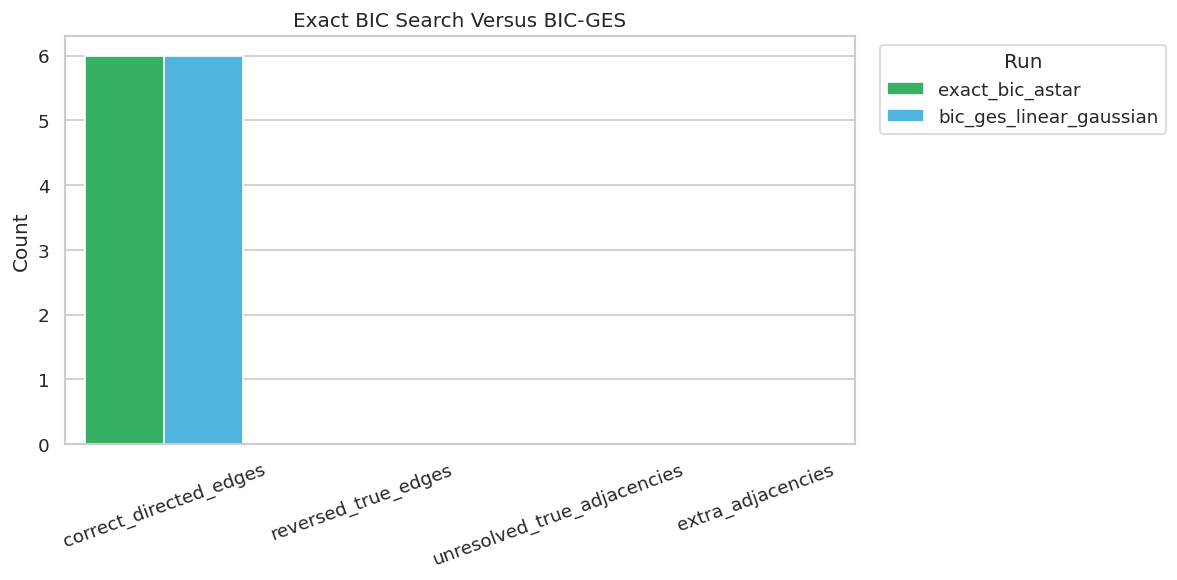

In [10]:
# Plot exact search versus GES graph metrics.
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = exact_vs_ges.melt(
    id_vars="run",
    value_vars=["correct_directed_edges", "reversed_true_edges", "unresolved_true_adjacencies", "extra_adjacencies"],
    var_name="metric",
    value_name="count",
)
sns.barplot(data=plot_df, x="metric", y="count", hue="run", ax=ax, palette=["#22c55e", "#38bdf8"])
ax.set_title("Exact BIC Search Versus BIC-GES")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Run", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_exact_vs_ges_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

The methods line up here. The next sections show how constraints and search-space size affect exact search even when the score itself stays the same.

#### Super-Structure Restrictions

A super-structure is a matrix of allowed edges. If an edge is not allowed by the super-structure, exact search cannot use it. Good super-structures encode valid prior knowledge and speed up search. Bad super-structures can force a wrong answer.

In [11]:
# Create a timing-based super-structure that allows only forward edges by role tier.
tiers = {
    "need": 0,
    "intent": 0,
    "match": 1,
    "engagement": 2,
    "renewal": 3,
    "support": 3,
}
forward_super_graph = np.zeros((len(VARIABLES), len(VARIABLES)))
for parent_name in VARIABLES:
    for child_name in VARIABLES:
        if parent_name == child_name:
            continue
        if tiers[parent_name] < tiers[child_name]:
            forward_super_graph[VARIABLES.index(parent_name), VARIABLES.index(child_name)] = 1

# Create an intentionally too-strict super-structure that forbids the true intent -> renewal edge.
too_strict_super_graph = forward_super_graph.copy()
too_strict_super_graph[VARIABLES.index("intent"), VARIABLES.index("renewal")] = 0

super_graph_rows = []
for label, super_graph in [
    ("forward_tier_super_graph", forward_super_graph),
    ("too_strict_super_graph", too_strict_super_graph),
]:
    adjacency, edge_table, stats, elapsed = run_exact_search(
        linear_df,
        label=label,
        search_method="astar",
        super_graph=super_graph,
        max_parents=None,
    )
    metrics = summarize_against_truth(edge_table, true_edges, label)
    super_graph_rows.append(
        {
            "run": label,
            "allowed_edges": int(super_graph.sum()),
            "elapsed_seconds": elapsed,
            "exact_bic_score_lower_is_better": total_exact_bic_score(linear_df.to_numpy(), adjacency),
            "learned_edge_count": int(adjacency.sum()),
            **stats,
            **metrics.iloc[0].drop(labels=["run"]).to_dict(),
        }
    )
    edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_{label}_edges.csv", index=False)

super_graph_comparison = pd.DataFrame(super_graph_rows)
super_graph_comparison.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_super_graph_comparison.csv", index=False)
display(super_graph_comparison)

,run,allowed_edges,elapsed_seconds,exact_bic_score_lower_is_better,learned_edge_count,n_parent_graphs_entries,while_iter,for_iter,n_closed,max_n_opened,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,forward_tier_super_graph,13,0.004514,-9950.952924,6,29,2,6,2,1,6,6,6,6,1.000000,1.000000,0,0,0,0
1,too_strict_super_graph,12,0.002456,-9276.461582,7,25,2,6,2,1,7,7,6,5,0.714286,0.833333,0,0,1,2


The valid forward super-structure preserves the correct graph while reducing the allowed search space. The too-strict version demonstrates the danger: if a true edge is forbidden, exact search can only find the best graph inside the wrong space.

#### Max-Parent Restrictions

`max_parents` limits how many parents any one node may have. This can greatly reduce parent-set enumeration. In this synthetic graph, the largest true parent set has size two, so `max_parents=2` should be safe while `max_parents=1` is too restrictive.

In [12]:
# Compare exact search under different max-parent constraints.
max_parent_rows = []
max_parent_edges = []
for max_parents in [1, 2, 3, None]:
    label = f"exact_bic_max_parents_{'none' if max_parents is None else max_parents}"
    adjacency, edge_table, stats, elapsed = run_exact_search(
        linear_df,
        label=label,
        search_method="astar",
        max_parents=max_parents,
    )
    metrics = summarize_against_truth(edge_table, true_edges, label)
    max_parent_rows.append(
        {
            "run": label,
            "max_parents": "none" if max_parents is None else max_parents,
            "elapsed_seconds": elapsed,
            "exact_bic_score_lower_is_better": total_exact_bic_score(linear_df.to_numpy(), adjacency),
            "learned_edge_count": int(adjacency.sum()),
            **stats,
            **metrics.iloc[0].drop(labels=["run"]).to_dict(),
        }
    )
    max_parent_edges.append(edge_table.assign(max_parents="none" if max_parents is None else max_parents))

max_parent_comparison = pd.DataFrame(max_parent_rows)
max_parent_edge_table = pd.concat(max_parent_edges, ignore_index=True)
max_parent_comparison.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_max_parent_comparison.csv", index=False)
max_parent_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_max_parent_edges.csv", index=False)

display(max_parent_comparison)
display(max_parent_edge_table)

,run,max_parents,elapsed_seconds,exact_bic_score_lower_is_better,learned_edge_count,n_parent_graphs_entries,while_iter,for_iter,n_closed,max_n_opened,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,exact_bic_max_parents_1,1,0.002837,-8325.637262,5,34,9,32,9,5,5,5,6,2,0.4,0.333333,3,0,1,0
1,exact_bic_max_parents_2,2,0.006583,-9950.952924,6,76,22,80,22,15,6,6,6,6,1.0,1.000000,0,0,0,0
2,exact_bic_max_parents_3,3,0.012072,-9950.952924,6,104,33,112,33,20,6,6,6,6,1.0,1.000000,0,0,0,0
3,exact_bic_max_parents_none,none,0.016099,-9950.952924,6,109,36,120,36,20,6,6,6,6,1.0,1.000000,0,0,0,0


,run,source,edge_type,target,max_parents
0,exact_bic_max_parents_1,intent,-->,renewal,1
1,exact_bic_max_parents_1,match,-->,need,1
2,exact_bic_max_parents_1,engagement,-->,match,1
3,exact_bic_max_parents_1,engagement,-->,support,1
4,exact_bic_max_parents_1,renewal,-->,engagement,1
5,exact_bic_max_parents_2,need,-->,match,2
6,exact_bic_max_parents_2,intent,-->,match,2
7,exact_bic_max_parents_2,intent,-->,renewal,2
8,exact_bic_max_parents_2,match,-->,engagement,2
9,exact_bic_max_parents_2,engagement,-->,renewal,2


The max-parent comparison shows the practical tradeoff. A correct limit can speed up search safely, but an overly tight limit prevents the score from selecting the true parent set for nodes that need multiple parents.

#### Variable-Count Scaling

Exact search scales with the number of variables, more than the number of rows. The code below runs exact search on prefixes of the variable list and records parent-graph and order-graph statistics.

In [13]:
# Measure how exact-search statistics grow with variable count.
scaling_rows = []
for variable_count in [3, 4, 5, 6]:
    subset_variables = VARIABLES[:variable_count]
    subset_df = linear_df[subset_variables]
    adjacency, edge_table, stats, elapsed = run_exact_search(
        subset_df,
        label=f"exact_bic_{variable_count}_variables",
        search_method="dp",
        max_parents=None,
    )
    scaling_rows.append(
        {
            "variable_count": variable_count,
            "theoretical_order_graph_nodes": 2 ** variable_count,
            "theoretical_unrestricted_parent_sets": variable_count * (2 ** (variable_count - 1)),
            "elapsed_seconds": elapsed,
            "learned_edge_count": int(adjacency.sum()),
            **stats,
        }
    )

variable_scaling = pd.DataFrame(scaling_rows)
variable_scaling.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_variable_count_scaling.csv", index=False)
display(variable_scaling)

,variable_count,theoretical_order_graph_nodes,theoretical_unrestricted_parent_sets,elapsed_seconds,learned_edge_count,n_parent_graphs_entries,n_order_graph_nodes,n_order_graph_edges
0,3,8,12,0.001045,2,10,8,12
1,4,16,32,0.002428,3,23,16,28
2,5,32,80,0.006053,5,61,32,73
3,6,64,192,0.015024,6,109,64,148


Even on this small example, the order-graph node count doubles with each added variable. That growth explains why exact search is best used as a small-graph benchmark or as part of a heavily constrained workflow.



#### Plot Scaling Diagnostics

A plot makes the growth pattern easier to see. The y-axis is log-scaled because combinatorial quantities grow quickly.

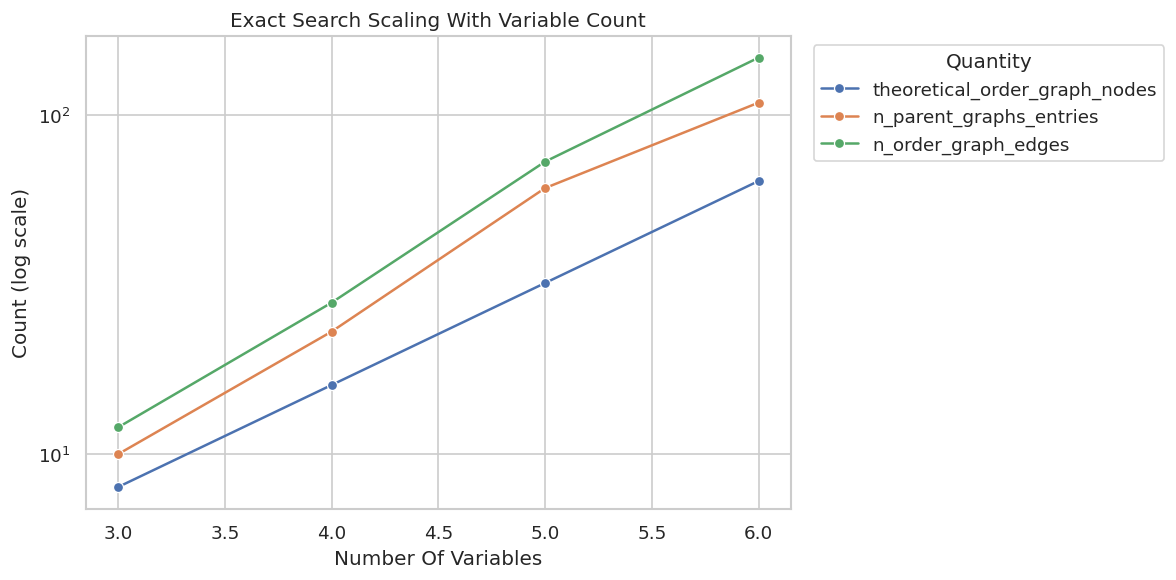

In [14]:
# Plot exact-search scaling diagnostics.
scaling_plot = variable_scaling.melt(
    id_vars="variable_count",
    value_vars=["theoretical_order_graph_nodes", "n_parent_graphs_entries", "n_order_graph_edges"],
    var_name="quantity",
    value_name="count",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=scaling_plot, x="variable_count", y="count", hue="quantity", marker="o", ax=ax)
ax.set_yscale("log")
ax.set_title("Exact Search Scaling With Variable Count")
ax.set_xlabel("Number Of Variables")
ax.set_ylabel("Count (log scale)")
ax.legend(title="Quantity", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_variable_count_scaling.png", dpi=160, bbox_inches="tight")
plt.show()

The plot shows why exact search is educational and often hard to operationalize. It gives a global optimum for the score, while the search space grows very quickly.

#### Sample-Size Sensitivity

Exact search optimizes the score for the available data. With smaller samples, local scores are noisier, so the optimal graph for the sample can differ from the optimal graph for the full dataset.

In [15]:
# Run exact search on subsamples to show sample-size sensitivity.
sample_rows = []
sample_edges = []
for sample_size in [100, 250, 500, 1000, len(linear_df)]:
    sample_df = linear_df.sample(n=sample_size, random_state=909 + sample_size)
    label = f"exact_bic_n_{sample_size}"
    adjacency, edge_table, stats, elapsed = run_exact_search(
        sample_df,
        label=label,
        search_method="astar",
        max_parents=None,
    )
    metrics = summarize_against_truth(edge_table, true_edges, label)
    sample_rows.append(
        {
            "run": label,
            "sample_size": sample_size,
            "elapsed_seconds": elapsed,
            "exact_bic_score_lower_is_better": total_exact_bic_score(sample_df.to_numpy(), adjacency),
            "learned_edge_count": int(adjacency.sum()),
            **stats,
            **metrics.iloc[0].drop(labels=["run"]).to_dict(),
        }
    )
    sample_edges.append(edge_table.assign(sample_size=sample_size))

sample_sensitivity = pd.DataFrame(sample_rows)
sample_sensitivity_edges = pd.concat(sample_edges, ignore_index=True)
sample_sensitivity.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_sample_size_sensitivity.csv", index=False)
sample_sensitivity_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_sample_size_sensitivity_edges.csv", index=False)

display(sample_sensitivity)
display(sample_sensitivity_edges.head(20))

,run,sample_size,elapsed_seconds,exact_bic_score_lower_is_better,learned_edge_count,n_parent_graphs_entries,while_iter,for_iter,n_closed,max_n_opened,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,exact_bic_n_100,100,0.007329,-364.561088,6,76,34,115,34,20,6,6,6,6,1.0,1.0,0,0,0,0
1,exact_bic_n_250,250,0.009556,-1017.879483,6,90,35,118,35,21,6,6,6,6,1.0,1.0,0,0,0,0
2,exact_bic_n_500,500,0.008247,-1825.968281,6,93,35,118,35,21,6,6,6,6,1.0,1.0,0,0,0,0
3,exact_bic_n_1000,1000,0.010401,-4033.888730,6,98,35,118,35,20,6,6,6,6,1.0,1.0,0,0,0,0
4,exact_bic_n_2500,2500,0.015248,-9950.952924,6,109,36,120,36,20,6,6,6,6,1.0,1.0,0,0,0,0


,run,source,edge_type,target,sample_size
0,exact_bic_n_100,need,-->,match,100
1,exact_bic_n_100,intent,-->,match,100
2,exact_bic_n_100,intent,-->,renewal,100
3,exact_bic_n_100,match,-->,engagement,100
4,exact_bic_n_100,engagement,-->,renewal,100
5,exact_bic_n_100,engagement,-->,support,100
6,exact_bic_n_250,need,-->,match,250
7,exact_bic_n_250,intent,-->,match,250
8,exact_bic_n_250,intent,-->,renewal,250
9,exact_bic_n_250,match,-->,engagement,250


The sample-size table shows that an exact optimizer can still produce sample-specific graphs. Exactness refers to optimizing the score for the observed sample, not to recovering causal truth regardless of data quality.

#### Plot Sample-Size Sensitivity

The sample-size plot shows whether recovery improves as the number of rows grows. This is the same diagnostic logic used in earlier notebooks, now applied to exact search.

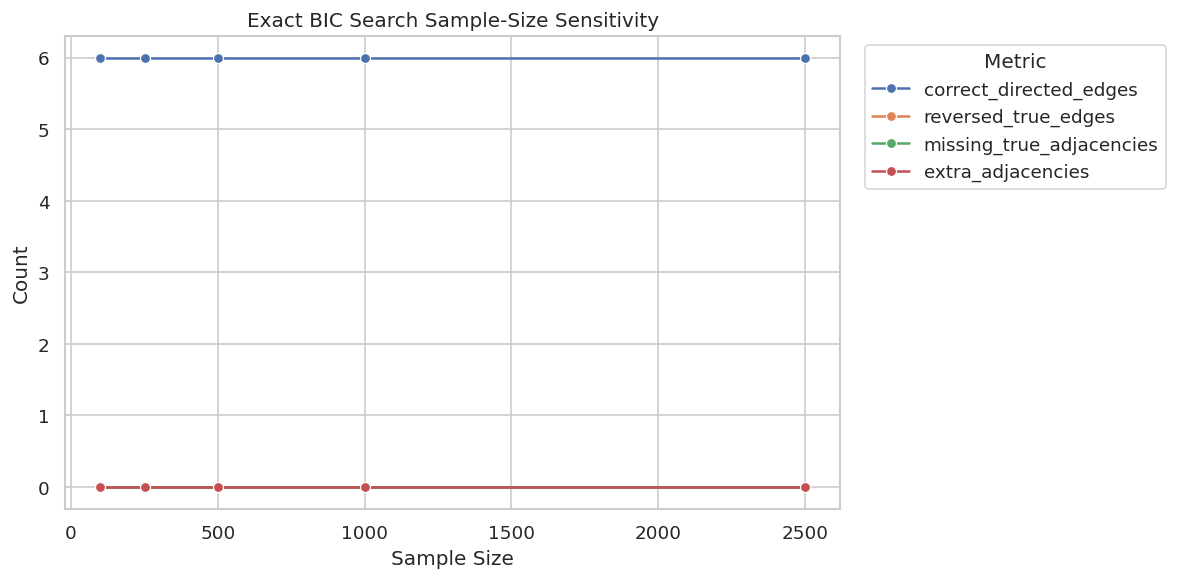

In [16]:
# Plot sample-size sensitivity for exact BIC search.
sample_plot = sample_sensitivity.melt(
    id_vars=["run", "sample_size"],
    value_vars=["correct_directed_edges", "reversed_true_edges", "missing_true_adjacencies", "extra_adjacencies"],
    var_name="metric",
    value_name="count",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=sample_plot, x="sample_size", y="count", hue="metric", marker="o", ax=ax)
ax.set_title("Exact BIC Search Sample-Size Sensitivity")
ax.set_xlabel("Sample Size")
ax.set_ylabel("Count")
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_sample_size_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()

The plot separates algorithmic optimality from statistical reliability. The optimizer is exact, but the score estimate becomes more reliable as sample size grows.

The lesson is robustness: a publishable conclusion should not hinge on one arbitrary threshold, one lucky sample split, or one narrow tuning choice.
<!-- result-implication-expanded -->


#### Score Comparison Across Candidate Graphs

This final score diagnostic compares several candidate graphs under the same exact BIC scoring function. Lower scores are better. This helps students see that exact search is choosing among graphs by total decomposable score.

In [17]:
# Compare total exact BIC scores for several candidate graphs.
empty_adjacency = np.zeros((len(VARIABLES), len(VARIABLES)))
true_adjacency = edge_table_to_adjacency(true_edge_table, VARIABLES)
exact_adjacency = edge_table_to_adjacency(exact_astar_edges, VARIABLES)
ges_adjacency = edge_table_to_adjacency(ges_edges, VARIABLES)

# A deliberately incomplete candidate that omits engagement -> renewal.
incomplete_adjacency = true_adjacency.copy()
incomplete_adjacency[VARIABLES.index("engagement"), VARIABLES.index("renewal")] = 0

candidate_scores = pd.DataFrame(
    [
        {"candidate_graph": "empty_graph", "edge_count": int(empty_adjacency.sum()), "exact_bic_score_lower_is_better": total_exact_bic_score(linear_df.to_numpy(), empty_adjacency)},
        {"candidate_graph": "true_graph", "edge_count": int(true_adjacency.sum()), "exact_bic_score_lower_is_better": total_exact_bic_score(linear_df.to_numpy(), true_adjacency)},
        {"candidate_graph": "exact_search_graph", "edge_count": int(exact_adjacency.sum()), "exact_bic_score_lower_is_better": total_exact_bic_score(linear_df.to_numpy(), exact_adjacency)},
        {"candidate_graph": "ges_graph", "edge_count": int(ges_adjacency.sum()), "exact_bic_score_lower_is_better": total_exact_bic_score(linear_df.to_numpy(), ges_adjacency)},
        {"candidate_graph": "incomplete_true_graph", "edge_count": int(incomplete_adjacency.sum()), "exact_bic_score_lower_is_better": total_exact_bic_score(linear_df.to_numpy(), incomplete_adjacency)},
    ]
).sort_values("exact_bic_score_lower_is_better")

candidate_scores.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_candidate_graph_score_comparison.csv", index=False)
display(candidate_scores)

,candidate_graph,edge_count,exact_bic_score_lower_is_better
1,true_graph,6,-9.950953e+03
2,exact_search_graph,6,-9.950953e+03
3,ges_graph,6,-9.950953e+03
4,incomplete_true_graph,5,-9.273215e+03
0,empty_graph,0,-1.665335e-12


The exact-search graph has the best score among these candidates. In this synthetic case it matches the true graph, but in real data the best-scoring graph should still be treated as a score-optimal candidate under assumptions.




## Reporting and Takeaways

### Exact Search Reporting Checklist

The checklist below turns the notebook into reusable guidance. Exact search can sound definitive, so reporting needs to make clear what is exact and what is still assumption-dependent.

| topic | question_to_answer | reporting_note |
| --- | --- | --- |
| score definition | Which score was optimized, and what assumptions does it make? | Exact search is exact for the chosen score, not for all possible causal criteria. |
| search method | Was A*, dynamic programming, or another exact method used? | Different exact methods should agree on the optimum under the same constraints. |
| search-space constraints | Were super-structures, required edges, or max-parent limits used? | Valid constraints can help; invalid constraints can force the wrong optimum. |
| scaling | How many variables were searched, and what were the parent-graph/order-graph statistics? | Exact search becomes expensive quickly as variable count grows. |
| sample reliability | Does the exact optimum stabilize as sample size changes? | The optimizer can be exact even when the sample score is noisy. |
| claim strength | Which edges are score-optimal candidates rather than confirmed causal facts? | A best-scoring DAG still needs assumptions, domain review, and sensitivity checks. |


The checklist preserves the main lesson. Exact search is a powerful benchmark for small graphs, but it does not remove the need to document scores, constraints, scaling limits, and uncertainty.

At this point, we have a complete exact-search workflow: BIC exact search with A* and DP, local parent-set scoring, parent-graph diagnostics, exact-vs-GES comparison, super-structure and max-parent constraints, scaling checks, sample-size sensitivity, candidate graph scoring, and reporting outputs. The next tutorial can move into LiNGAM, where non-Gaussianity helps orient causal directions that Markov-equivalence methods may leave ambiguous.
